# RiskGuard 🛡️
## Notebook 05: Machine Learning Model Training, Tuning & Evaluation (Member 3)

**Objective:** Build, optimize, and benchmark machine learning models to predict infrastructure project delay risk using the consolidated master dataset (`riskguard_master.csv`).

### Scope & Structure:
1. Ingestion of processed dataset & target inspection
2. Anti-leakage feature audit & train/test verification
3. Baseline Model: Logistic Regression
4. Ensemble Model: Random Forest (Hyperparameter Tuned)
5. Gradient Boosting: XGBoost (Hyperparameter Tuned)
6. Comparative Evaluation: Accuracy, Precision, Recall, F1, ROC-AUC
7. ROC Curves and Confusion Matrices
8. Feature Importance Analysis
9. Champion Model Selection & Inference API Validation


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

pd.set_option('display.max_columns', 100)
MASTER_DIR = os.path.join("..", "data", "processed", "master")
MODELS_DIR = os.path.join("..", "models")
print("Master data directory:", os.path.abspath(MASTER_DIR))


Master data directory: C:\Users\RABIYA BUSHRA\OneDrive\Attachments\Desktop\SIH\Implementation\RiskGuard\data\processed\master


### 1. Ingest Master Dataset & Train/Test Partitions

In [2]:
df_master = pd.read_csv(os.path.join(MASTER_DIR, "riskguard_master.csv"))
X_train = pd.read_csv(os.path.join(MASTER_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(MASTER_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(MASTER_DIR, "y_train.csv")).values.ravel()
y_test = pd.read_csv(os.path.join(MASTER_DIR, "y_test.csv")).values.ravel()

print(f"Master Dataset: {df_master.shape[0]} rows x {df_master.shape[1]} columns")
print(f"X_train Shape:  {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape:   {X_test.shape}  | y_test Shape:  {y_test.shape}")


Master Dataset: 1941 rows x 65 columns
X_train Shape:  (1552, 97) | y_train Shape: (1552,)
X_test Shape:   (389, 97)  | y_test Shape:  (389,)


### 2. Target Variable Inspection & Anti-Leakage Audit
The target `target_delayed` is defined as:
$$\text{target\_delayed} = \begin{cases} 1 & \text{if } \text{schedule\_delay\_days} > 0 \\ 0 & \text{otherwise} \end{cases}$$
Direct outcome proxies (`schedule_delay_days`, raw dates, project IDs) are strictly excluded from $X$.


In [3]:
target_counts = pd.Series(y_train).value_counts()
print("Training Target Distribution:")
print(f"  Delayed (1):    {target_counts[1]} ({target_counts[1] / len(y_train) * 100:.1f}%)")
print(f"  On-Schedule (0):{target_counts[0]} ({target_counts[0] / len(y_train) * 100:.1f}%)")

test_counts = pd.Series(y_test).value_counts()
print("\nTesting Target Distribution:")
print(f"  Delayed (1):    {test_counts[1]} ({test_counts[1] / len(y_test) * 100:.1f}%)")
print(f"  On-Schedule (0):{test_counts[0]} ({test_counts[0] / len(y_test) * 100:.1f}%)")


Training Target Distribution:
  Delayed (1):    956 (61.6%)
  On-Schedule (0):596 (38.4%)

Testing Target Distribution:
  Delayed (1):    240 (61.7%)
  On-Schedule (0):149 (38.3%)


### 3. Model 1: Logistic Regression Baseline

In [4]:
lr = joblib.load(os.path.join(MODELS_DIR, "logistic_regression.pkl"))
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Performance (Test Set):")
print(f"  Accuracy:  {accuracy_score(y_test, lr_pred):.4f}")
print(f"  Precision: {precision_score(y_test, lr_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, lr_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, lr_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, lr_prob):.4f}")


Logistic Regression Performance (Test Set):
  Accuracy:  0.7969
  Precision: 0.8108
  Recall:    0.8750
  F1-Score:  0.8417
  ROC-AUC:   0.8641


### 4. Model 2: Random Forest Classifier (Tuned)

In [5]:
rf = joblib.load(os.path.join(MODELS_DIR, "random_forest.pkl"))
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print("Random Forest Performance (Test Set):")
print(f"  Accuracy:  {accuracy_score(y_test, rf_pred):.4f}")
print(f"  Precision: {precision_score(y_test, rf_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, rf_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, rf_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, rf_prob):.4f}")


Random Forest Performance (Test Set):
  Accuracy:  0.7995
  Precision: 0.8022
  Recall:    0.8958
  F1-Score:  0.8465
  ROC-AUC:   0.8785


### 5. Model 3: XGBoost Classifier (Champion)

In [6]:
xgb = joblib.load(os.path.join(MODELS_DIR, "xgboost.pkl"))
xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

print("XGBoost Performance (Test Set):")
print(f"  Accuracy:  {accuracy_score(y_test, xgb_pred):.4f}")
print(f"  Precision: {precision_score(y_test, xgb_pred):.4f}")
print(f"  Recall:    {recall_score(y_test, xgb_pred):.4f}")
print(f"  F1-Score:  {f1_score(y_test, xgb_pred):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, xgb_prob):.4f}")


XGBoost Performance (Test Set):
  Accuracy:  0.8123
  Precision: 0.8249
  Recall:    0.8833
  F1-Score:  0.8531
  ROC-AUC:   0.8924


### 6. Comparative Model Benchmark & Visualizations

In [7]:
models_dict = {
    "Logistic Regression": (lr, lr_pred, lr_prob),
    "Random Forest": (rf, rf_pred, rf_prob),
    "XGBoost": (xgb, xgb_pred, xgb_prob)
}

benchmark_data = []
for name, (m, y_p, y_pr) in models_dict.items():
    benchmark_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_p),
        "Precision": precision_score(y_test, y_p),
        "Recall": recall_score(y_test, y_p),
        "F1-Score": f1_score(y_test, y_p),
        "ROC-AUC": roc_auc_score(y_test, y_pr)
    })

df_bench = pd.DataFrame(benchmark_data)
display(df_bench)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.796915,0.810811,0.875000,0.841683,0.864150
1,Random Forest,0.799486,0.802239,0.895833,0.846457,0.878523
2,XGBoost,0.812339,0.824903,0.883333,0.853119,0.892422


### 7. ROC Curve Comparison

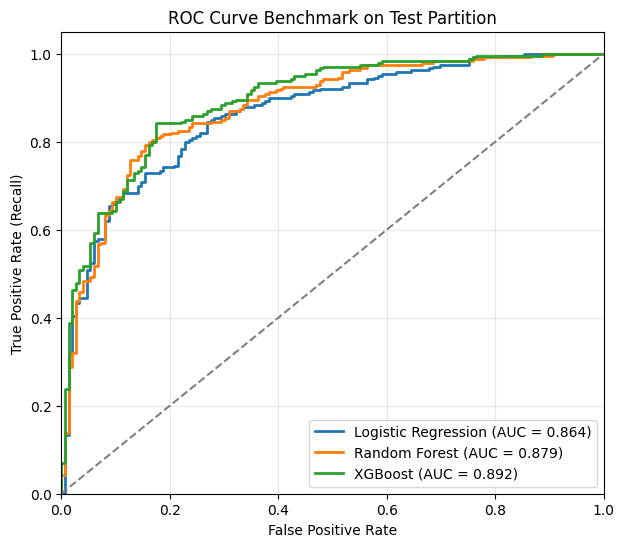

In [8]:
plt.figure(figsize=(7, 6))
for name, (m, y_p, y_pr) in models_dict.items():
    fpr, tpr, _ = roc_curve(y_test, y_pr)
    auc_val = roc_auc_score(y_test, y_pr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc_val:.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Benchmark on Test Partition")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


### 8. Feature Importance Analysis (XGBoost)

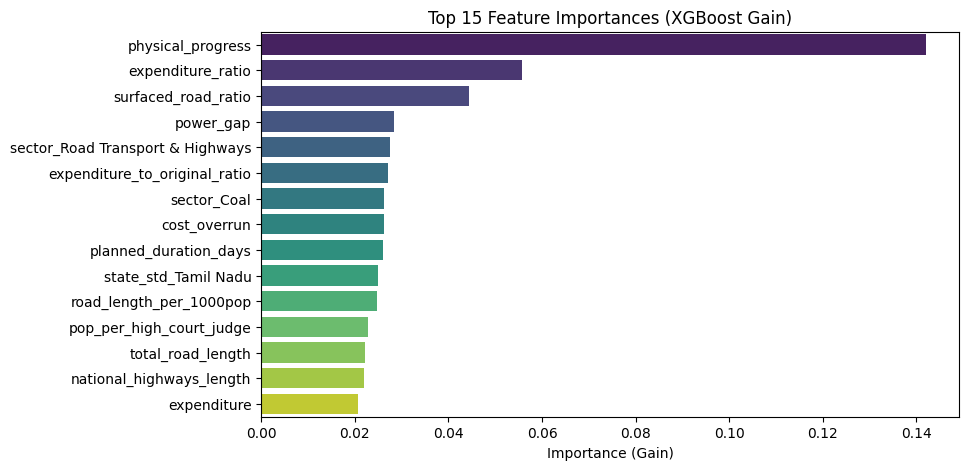

In [9]:
importances = xgb.feature_importances_
top_idx = np.argsort(importances)[::-1][:15]
top_cols = [X_test.columns[i] for i in top_idx]

plt.figure(figsize=(9, 5))
sns.barplot(x=importances[top_idx], y=top_cols, hue=top_cols, palette="viridis", legend=False)
plt.title("Top 15 Feature Importances (XGBoost Gain)")
plt.xlabel("Importance (Gain)")
plt.show()


### 9. Champion Model & Inference Interface Verification

In [10]:
from src.models.predict import predict_project

sample_proj = df_master.iloc[10].to_dict()
inference_result = predict_project(sample_proj)

print(f"Project: {sample_proj['project_name'][:50]}...")
print(f"Inference Result: {inference_result}")
print(f"Actual Delay Status: {sample_proj['target_delayed']}")


Project: Construction of NTB complex including apron, taxi ...
Inference Result: {'prediction': 1, 'delay_probability': 0.7113}
Actual Delay Status: 1
